In [54]:
from collections import defaultdict
import pandas as pd
import os
import csv
from itertools import combinations
import kagglehub

dir_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
path = os.path.join(dir_path, "spotify_dataset.csv")

playlists = defaultdict(list)
transactions = []

# read the file in chunks
for chunk in pd.read_csv(path, chunksize=50000, on_bad_lines="skip"):

    # titles of csv columns were imported with extra ' 's
    # drop rows that have any null values in the row
    chunk.columns = [c.replace('"', '').strip() for c in chunk.columns]
    chunk = chunk.dropna(subset=["user_id", "playlistname", "trackname", "artistname"])

    # make the key unique with (userid, playlist) in case a playlist name is the same
    # make the value unique in case there's a song with the same title
    for row in chunk.itertuples(index=False):
        key = (row.user_id, row.playlistname)
        song = f"{row.trackname} - {row.artistname}"
        playlists[key].append(song)

# create a transactions array like the one we did in class
transactions = [frozenset(songs) for songs in playlists.values()]
print(len(transactions))

231560


In [55]:
# get a sense of how different support thresholds prune our items so we can pick the right one
from collections import Counter

# gives a count of how many transactions each song appears in aka support count
song_counts = Counter(item for t in transactions for item in t)

num_trans= len(transactions)  # 231560

# experimenting with some thresholds

print(f"Total number of items (non-duplicates) in across all transactions: {len(song_counts)}")

for min_support in [0.002, 0.001, 0.005, 0.01, 0.02]:
    passes_threshold = sum(1 for c in song_counts.values() if c / num_trans >= min_support)
    print(f"min_support={min_support:.4f} → {passes_threshold:,} items pass this threshold")


Total number of items (non-duplicates) in across all transactions: 2789644
min_support=0.0020 → 1,107 items pass this threshold
min_support=0.0010 → 3,747 items pass this threshold
min_support=0.0050 → 102 items pass this threshold
min_support=0.0100 → 3 items pass this threshold
min_support=0.0200 → 0 items pass this threshold


In [56]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# filtering to pre-prune before Apriori (otherwise will take very long)

# remove playlists with only one song (can't generate rules from)
# grab the top 200 songs using support counts from song_counts from before
top_100 = {song for song, count in song_counts.most_common(100)}
print("got top songs!")

# keep only the top 200 in the filtered_transactions that we'll use for Apriori
filtered_transactions = [[s for s in t if s in top_100] for t in transactions]
print("filtered based off top songs")

filtered_transactions = [t for t in filtered_transactions if len(t) >= 2] # removes playlists with only one song 
print(len(filtered_transactions))

te = TransactionEncoder()
df = pd.DataFrame(te.fit_transform(filtered_transactions), columns=te.columns_)
freq_items = apriori(df, min_support=0.0005, use_colnames=True, verbose=1, max_len=3)
freq_items['length'] = freq_items['itemsets'].apply(len)

print(f"Frequent itemsets found: {len(freq_items):,}")

got top songs!
filtered based off top songs
23339
Processing 485100 combinations | Sampling itemset size 3
Frequent itemsets found: 139,985


In [57]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.70)
rules = rules.sort_values('lift', ascending=False)
print(f"Rules found: {len(rules):,}")
print(rules[['antecedents','consequents','support','confidence','lift']].head(10))

Rules found: 296
                                           antecedents  \
201  frozenset({Get Lucky - Daft Punk, Instant Crus...   
4    frozenset({Fix You - Coldplay, A Sky Full of S...   
8    frozenset({A Sky Full of Stars - Coldplay, Yel...   
200  frozenset({Get Lucky - Daft Punk, Lose Yoursel...   
73   frozenset({Lose Yourself to Dance - Daft Punk,...   
269  frozenset({The Scientist - Coldplay, Summer - ...   
22   frozenset({Breezeblocks - alt-J, Smells Like T...   
197  frozenset({Fix You - Coldplay, Yellow - Coldpl...   
295  frozenset({Viva La Vida - Coldplay, Yellow - C...   
294  frozenset({The Scientist - Coldplay, Viva La V...   

                                         consequents   support  confidence  \
201  frozenset({Lose Yourself to Dance - Daft Punk})  0.028450    0.915862   
4                      frozenset({Magic - Coldplay})  0.005184    0.724551   
8                      frozenset({Magic - Coldplay})  0.004028    0.717557   
200           frozenset({Instant

In [58]:
# we have our strong rules above. now we want to build how we recommend using that.
# first filter out metrics above a certain threshold
# for the input playlist, if it has the antencdent we recommmend the consequent if not already contained
def recommend_songs(input_playlist, rules, top_n=50):
    filtered_rules = rules[(rules['support'] >= 0.005) & (rules['lift'] >= 2.0)].copy()
    recommendations = []
    

    for _, row in filtered_rules.iterrows():
        antecedent = set(row['antecedents']) # songs we have
        consequent = set(row['consequents']) # songs we would recommend

        # if the playlist contains all the songs we have, recommend if not already in the playlist
        if antecedent.issubset(input_playlist):
            for song in consequent:
                if song not in input_playlist:
                    recommendations.append((song, antecedent, consequent, row['confidence'], row['lift']))

    # sort by lift (or confidence)
    recommendations.sort(key=lambda x: x[4], reverse=True)  # lift
    return recommendations[:top_n]

input_playlist = {
    "Yellow - Coldplay",
    "Fix You - Coldplay",
    "Viva La Vida - Coldplay"
}

recommended_songs = recommend_songs(input_playlist, rules)

print(f"=== Final Recommended Songs For an Example Playlist ===")
print(f"{'title':30} {'antecedent':50} {'consequent':29} {'confidence':20} {'lift'}")
for song, antecedent, consequent, conf, lift in recommended_songs:

    print(f"{song:30} {str(antecedent):30} {str(consequent):30} {conf:15.2f} {lift:15.2f}")



=== Final Recommended Songs For an Example Playlist ===
title                          antecedent                                         consequent                    confidence           lift
The Scientist - Coldplay       {'Fix You - Coldplay', 'Yellow - Coldplay'} {'The Scientist - Coldplay'}              0.77           14.79
The Scientist - Coldplay       {'Viva La Vida - Coldplay', 'Yellow - Coldplay'} {'The Scientist - Coldplay'}              0.76           14.70
The Scientist - Coldplay       {'Viva La Vida - Coldplay', 'Fix You - Coldplay'} {'The Scientist - Coldplay'}              0.72           13.91


In [59]:
# training and validation on playlists (hide 20%, run Apriori/recommend_songs() on the other 80%)
import random
def split_playlist(transactions, test_ratio=0.2):
    playlists = list(transactions) 
    random.shuffle(playlists) # randomize the split
    
    split = int(len(playlists) * (1 - test_ratio))

    # first 80% of all transactions are training, rest is testing.
    train = playlists[:split]
    test = playlists[split:]
    return train, test

training_set, test_set = split_playlist(transactions)
print(f"Training set length: {len(training_set):,}")
print(f"Test set length: {len(test_set):,}")

Training set length: 185,248
Test set length: 46,312


In [60]:
# run Apriori on the training set
# generating rules form the found frequent itemsets of songs

# count songs using training data only
training_song_counts = Counter(item for t in training_set for item in t)

# keep only top 100 songs from the training set
top_100_train = {song for song, count in training_song_counts.most_common(100)}
print("got top training songs!")

# filter training transactions
filtered_training = [[s for s in t if s in top_100_train] for t in training_set]
print("filtered training transactions")

# remove short playlists
filtered_training = [t for t in filtered_training if len(t) >= 2]

# encode
te = TransactionEncoder()
df = pd.DataFrame(te.fit_transform(filtered_training), columns=te.columns_)
training_freq_items = apriori(df, min_support=0.0001, use_colnames=True, verbose=1, max_len=3)
training_freq_items['length'] = training_freq_items['itemsets'].apply(len)

training_rules = association_rules(training_freq_items, metric='confidence', min_threshold=0.70)
print("Training transactions:", len(training_set))
print("Frequent itemsets found:", len(training_freq_items))
print("Rules found:", len(training_rules))

got top training songs!
filtered training transactions
Processing 485100 combinations | Sampling itemset size 3
Training transactions: 185248
Frequent itemsets found: 166375
Rules found: 398


In [61]:
# out of all the recommended songs, how many are in the playlist
# returns a ratio for ONE playlist
def recommendation_score(recommended_songs, hidden_song_set, rec_num=50):
    top_recs = recommended_songs[:rec_num]
    if not top_recs:
        return 0
    
    hits = sum(1 for r in top_recs if r[0] in hidden_song_set)
    return hits/len(top_recs)

def evaluate_model(transactions, rules, top_songs, k=3):
    scores = []

    for i, playlist in enumerate(transactions):
        playlist = frozenset(s for s in playlist if s in top_songs) 

        if len(playlist) < 2:
            continue

        if i % 1000 == 0:
            print(f"Processed {i} playlists")

        # split the playlist and feed training set to model
        playlist = list(playlist)
        random.shuffle(playlist)
        split = int(len(playlist) * 0.8)
        input_playlist = playlist[:split]
        hidden_songs = set(playlist[split:])

        recs = recommend_songs(input_playlist, rules)
        score = recommendation_score(recs, hidden_songs)
        scores.append(score)

    return sum(scores) / len(scores) if scores else 0

# average hit score over all playlists
overall_score = evaluate_model(test_set, training_rules, top_100_train)
print("Overall Hits:", overall_score)

Processed 4000 playlists
Processed 8000 playlists
Processed 13000 playlists
Processed 14000 playlists
Processed 24000 playlists
Processed 26000 playlists
Processed 43000 playlists
Overall Hits: 0.07806633949995079


# Plots and Evaluative Graphs

In [62]:
#we have our score and now its time to plot the results
import matplotlib.pyplot as plt
import random
import numpy as np
COLOR_MBA = '#1DB954'
#using random recommendations and popularity recommendations from previous cells
#TODO: Plot an MBA vs random, MBA vs popularity 
def random_recommend(input_playlist, song_pool, top_n=50, rng=random):
    candidates = [s for s in song_pool if s not in input_playlist]
    #skip ones in playlist already, sampling randomly
    chosen = rng.sample(candidates, min(top_n, len(candidates)))
    return[(s, None, None, 0.0, 0.0) for s in chosen]

def popularity_rec(input_playlist, ranked_songs, top_n = 50):
    #rec most popular in ranked order if not in playlist
    recs = []
    for s in ranked_songs:
        if s in input_playlist:
            continue
        recs.append((s, None, None, 0.0, 0.0))
        if(len(recs) == top_n):
            break
    return recs
#pools
song_pool =list(top_100_train)
popularity = [s for s, _ in training_song_counts.most_common(100)]

#seed for fixed splitting
SEED = 42
EVAL_SAMPLE_SIZE = None #5000 for iterating

rng_split = random.Random(SEED)
test_pool = list(test_set)
#sampling
if EVAL_SAMPLE_SIZE is not None and EVAL_SAMPLE_SIZE < len(test_pool):
    test_pool = rng_split.sample(test_pool, EVAL_SAMPLE_SIZE)

eval_splits = []
for pl in test_pool:
    pl_filter = [s for s in pl if s in top_100_train]
    if len(pl_filter) < 2:
        continue
    p = list(pl_filter)
    rng_split.shuffle(p)
    cut = int(len(p) * 0.8)
    eval_splits.append((p[:cut], set(p[cut:])))

print(f"built {len(eval_splits):,} splits for evaluation")

built 4,677 splits for evaluation


In [63]:
#now we evaluate each
def evaluate_plots(splits, recommender_fn, kval = (1,3,5,10,20,50), log_every=5000):
    k_max = max(kval)
    scores = {k: [] for k in kval}

    #loop to test all k
    for i, (input_pl, hidden) in enumerate(splits):
        if i % log_every == 0:
            print(f"{i:,}/{len(splits):,}")
        recs = recommender_fn(input_pl)
        rec_songs = [r[0] for r in recs[:k_max]]
        for k in kval:
            top_k = rec_songs[:k]
            scores[k].append(sum(s in hidden for s in top_k)/ k)
    return scores

#wrap
mba_fn = lambda pl: recommend_songs(pl, training_rules, top_n=50)
random_fn = lambda pl: random_recommend(pl, song_pool, top_n=50, rng = random.Random(SEED))
popularity_fn =lambda pl: popularity_rec(pl, popularity, top_n=50)

#check
print("eval MBA...")
mba_scores = evaluate_plots(eval_splits, mba_fn)
print("eval random...")
rand_scores = evaluate_plots(eval_splits, random_fn)
print("eval popularity")
pop_scores = evaluate_plots(eval_splits, popularity_fn)

#means at each
mba_mean = {k: np.mean(v) for k, v in mba_scores.items()}
rand_mean = {k: np.mean(v) for k, v in rand_scores.items()}
pop_mean = {k: np.mean(v) for k, v in pop_scores.items()}
print("MBA Hit w/50:", mba_mean[50])
print("Rand Hit w/50:", rand_mean[50])
print("Pop Hit w/50:", pop_mean[50])

eval MBA...
0/4,677
eval random...
0/4,677
eval popularity
0/4,677
MBA Hit w/50: 0.0031772503741714776
Rand Hit w/50: 0.017417147744280524
Pop Hit w/50: 0.01908488347231131


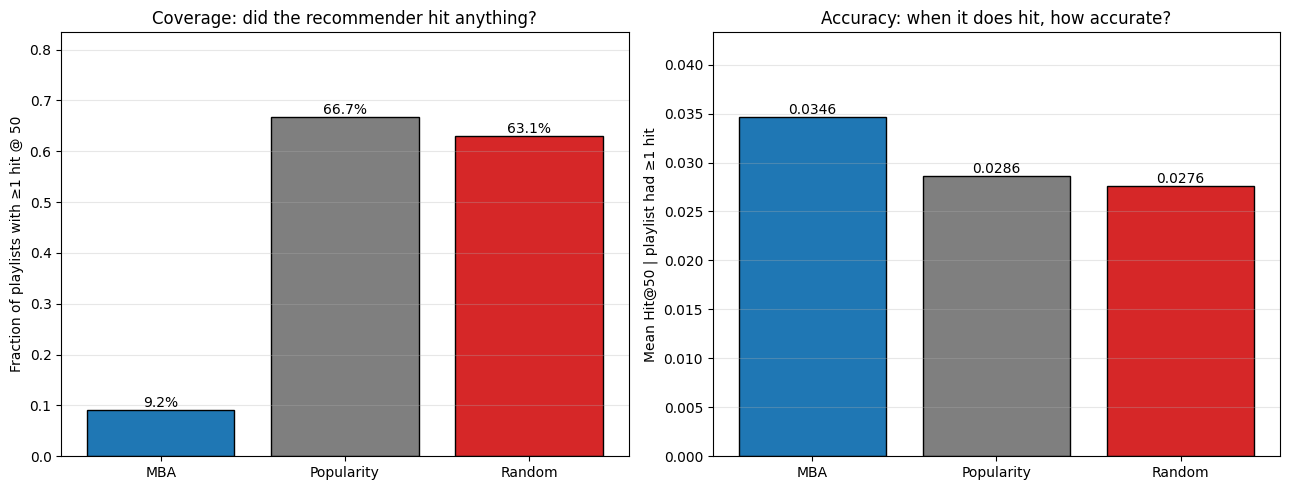

In [64]:
#plot 3: hit distr
def coverage(scores_at_50):
    #percentage of playlists that got a hit in recommendations
    return np.mean([s > 0 for s in scores_at_50])

cov = {
    "MBA":        coverage(mba_scores[50]),
    "Popularity": coverage(pop_scores[50]),
    "Random":     coverage(rand_scores[50]),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Coverage bar chart — % of playlists with any hit
axes[0].bar(cov.keys(), cov.values(),
            color=["#1f77b4", "#7f7f7f", "#d62728"], edgecolor="black")
for i, (name, v) in enumerate(cov.items()):
    axes[0].text(i, v, f"{v*100:.1f}%", ha="center", va="bottom")
axes[0].set_ylabel("Fraction of playlists with ≥1 hit @ 50")
axes[0].set_title("Coverage: did the recommender hit anything?")
axes[0].set_ylim(0, max(cov.values()) * 1.25)
axes[0].grid(axis="y", alpha=0.3)

#conditional precision when playlist receives a hit, how precise was the hit
def conditional_mean(scores):
    pos = [s for s in scores if s > 0]
    return np.mean(pos) if pos else 0

cond = {
    "MBA":        conditional_mean(mba_scores[50]),
    "Popularity": conditional_mean(pop_scores[50]),
    "Random":     conditional_mean(rand_scores[50]),
}
axes[1].bar(cond.keys(), cond.values(),
            color=["#1f77b4", "#7f7f7f", "#d62728"], edgecolor="black")
for i, (name, v) in enumerate(cond.items()):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")
axes[1].set_ylabel("Mean Hit@50 | playlist had ≥1 hit")
axes[1].set_title("Accuracy: when it does hit, how accurate?")
axes[1].set_ylim(0, max(cond.values()) * 1.25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

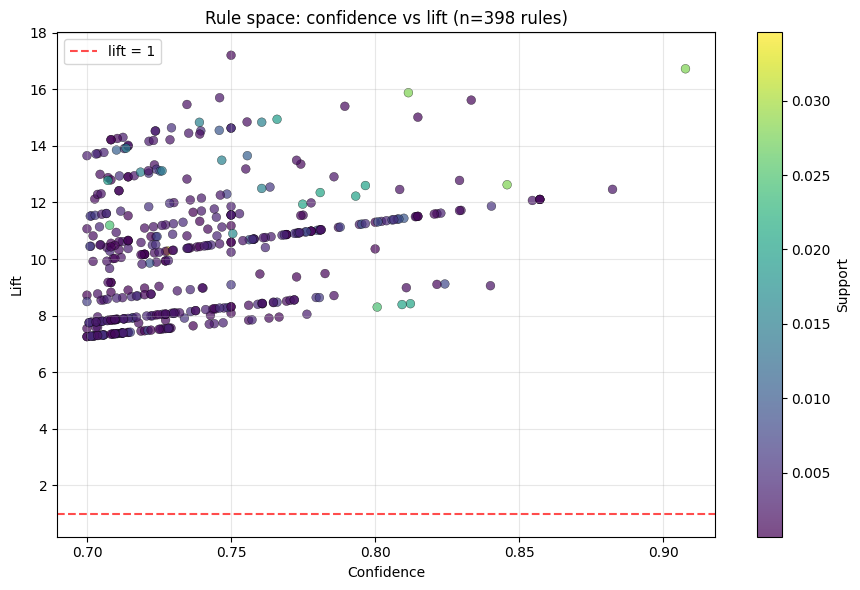

In [65]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    training_rules['confidence'],
    training_rules['lift'],
    c=training_rules['support'],
    cmap='viridis',
    alpha=0.7,
    s=40,
    edgecolors='black',
    linewidths=0.3
)

ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='lift = 1')
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title(f'Rule space: confidence vs lift (n={len(training_rules):,} rules)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Support')

plt.tight_layout()
plt.show()

In [66]:
# printing the top rules sorted by lift
def truncate(s, width):
    """Cut long song-name strings so the table stays readable."""
    return s if len(s) <= width else s[:width-1] + "…"

top_lift_rules = training_rules.nlargest(10, 'lift').reset_index(drop=True)

ANT_W, CON_W = 32, 32   # antecedent / consequent column widths
HEADER = (f'{"#":>3} | {"Antecedents":<{ANT_W}} | {"Consequents":<{CON_W}} | '
          f'{"Support":>8} | {"Conf":>6} | {"Lift":>7}')

print("\n=== Top 10 Rules by Lift ===")
print(HEADER)
print('-' * len(HEADER))
for i, row in top_lift_rules.iterrows():
    ant = truncate(', '.join(row['antecedents']), ANT_W)
    con = truncate(', '.join(row['consequents']), CON_W)
    print(f'{i+1:>3} | {ant:<{ANT_W}} | {con:<{CON_W}} | '
          f'{row["support"]:>8.4f} | {row["confidence"]:>6.4f} | {row["lift"]:>7.2f}')


=== Top 10 Rules by Lift ===
  # | Antecedents                      | Consequents                      |  Support |   Conf |    Lift
-------------------------------------------------------------------------------------------------------
  1 | The Scientist - Coldplay, Summe… | Magic - Coldplay                 |   0.0010 | 0.7500 |   17.20
  2 | Instant Crush - Daft Punk, Get … | Lose Yourself to Dance - Daft P… |   0.0279 | 0.9077 |   16.72
  3 | Lose Yourself to Dance - Daft P… | Instant Crush - Daft Punk        |   0.0279 | 0.8115 |   15.88
  4 | Breezeblocks - alt-J, Smells Li… | Come As You Are - Nirvana        |   0.0025 | 0.7460 |   15.70
  5 | Party Rock Anthem - LMFAO, Team… | Dark Horse - Katy Perry          |   0.0011 | 0.8333 |   15.62
  6 | Lose Yourself to Dance - Daft P… | Come As You Are - Nirvana        |   0.0019 | 0.7347 |   15.46
  7 | Lose Yourself to Dance - Daft P… | The Scientist - Coldplay         |   0.0016 | 0.7895 |   15.40
  8 | Billie Jean - Single Version

## Comparing to SVD w/same graphs

In [67]:
def precision_at_k(ranked, holdout, k):
    return len(set(ranked[:k]) & set(holdout)) / k

def recall_at_k(ranked, holdout, k):
    if len(holdout) == 0:
        return 0.0
    return len(set(ranked[:k]) & set(holdout)) / len(holdout)
               
def f1_at_k(p, r):
    return 2*p *r/(p+r) if (p+r) > 0 else 0.0

K_VALUES = [1,5,10,20,50]

def evaluate_prf(splits, recommender_fn, k_values=K_VALUES, log_every=5000, label=""):
    results = {k: {'p': [], 'r': [], 'f1': []} for k in k_values}
    k_max = max(k_values)

    for i, (input_pl, hidden) in enumerate(splits):
        if len(hidden) == 0:
            continue
        if i % log_every == 0:
            print(f" [{label}] {i:,}/{len(splits):,}")
        ranked =[r[0] for r in recommender_fn(input_pl)[:k_max]]
        for k in k_values:
            p = precision_at_k(ranked, hidden, k)
            r = recall_at_k(ranked, hidden, k)
            results[k]['p'].append(p)
            results[k]['r'].append(r)
            results[k]['f1'].append(f1_at_k(p,r))
    return results

print("Evaluating MBA...")
mba_results  = evaluate_prf(eval_splits, mba_fn,        label="MBA")
print("Evaluating Popularity...")
pop_results  = evaluate_prf(eval_splits, popularity_fn, label="Pop")
print("Evaluating Random...")
rand_results = evaluate_prf(eval_splits, random_fn,     label="Rand")

def print_table(results, name):
    print(f"\n=== {name} ===")
    print(f'{"k":>5} | {"Precision@k":>12} | {"Recall@k":>10} | {"F1@k":>8}')
    print('-' * 46)
    for k in K_VALUES:
        p = np.mean(results[k]['p'])
        r = np.mean(results[k]['r'])
        f = np.mean(results[k]['f1'])
        print(f'{k:>5} | {p:>12.4f} | {r:>10.4f} | {f:>8.4f}')

print_table(mba_results,  "MBA (Apriori)")
print_table(pop_results,  "Popularity")
print_table(rand_results, "Random")

Evaluating MBA...
 [MBA] 0/4,677
Evaluating Popularity...
 [Pop] 0/4,677
Evaluating Random...
 [Rand] 0/4,677

=== MBA (Apriori) ===
    k |  Precision@k |   Recall@k |     F1@k
----------------------------------------------
    1 |       0.0821 |     0.0578 |   0.0632
    5 |       0.0196 |     0.0630 |   0.0275
   10 |       0.0098 |     0.0631 |   0.0160
   20 |       0.0049 |     0.0631 |   0.0088
   50 |       0.0020 |     0.0631 |   0.0037

=== Popularity ===
    k |  Precision@k |   Recall@k |     F1@k
----------------------------------------------
    1 |       0.0368 |     0.0242 |   0.0271
    5 |       0.0321 |     0.0960 |   0.0442
   10 |       0.0281 |     0.1667 |   0.0453
   20 |       0.0240 |     0.2904 |   0.0427
   50 |       0.0191 |     0.5871 |   0.0363

=== Random ===
    k |  Precision@k |   Recall@k |     F1@k
----------------------------------------------
    1 |       0.0165 |     0.0088 |   0.0106
    5 |       0.0169 |     0.0496 |   0.0233
   10 |       0

### plots

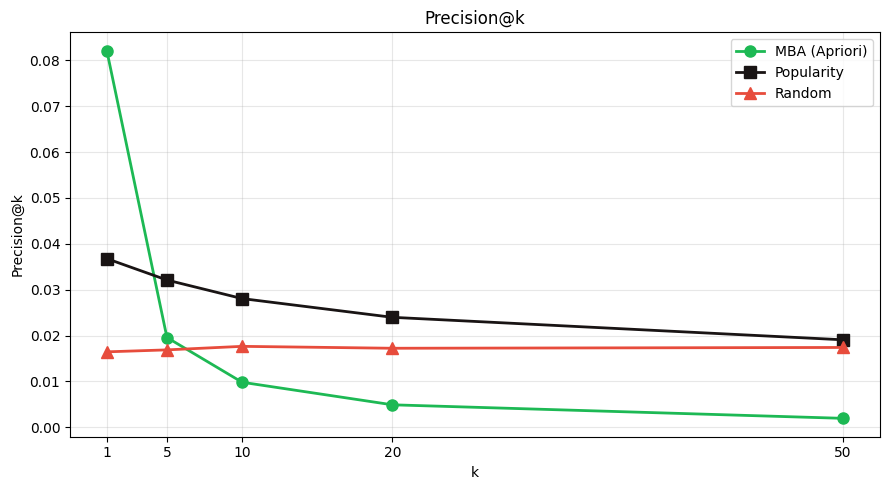

In [68]:
def means(results, metric):
    return [np.mean(results[k][metric]) for k in K_VALUES]

mba_p,  mba_r,  mba_f  = means(mba_results, 'p'),  means(mba_results, 'r'),  means(mba_results, 'f1')
pop_p,  pop_r,  pop_f  = means(pop_results, 'p'),  means(pop_results, 'r'),  means(pop_results, 'f1')
rand_p, rand_r, rand_f = means(rand_results, 'p'), means(rand_results, 'r'), means(rand_results, 'f1')

COLOR_MBA = '#1DB954'
COLOR_POP = '#191414'
COLOR_RAND = '#e74c3c'

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_VALUES, mba_p,  'o-', color=COLOR_MBA,  linewidth=2, markersize=8, label='MBA (Apriori)')
ax.plot(K_VALUES, pop_p,  's-', color=COLOR_POP,  linewidth=2, markersize=8, label='Popularity')
ax.plot(K_VALUES, rand_p, '^-', color=COLOR_RAND, linewidth=2, markersize=8, label='Random')
ax.set_xlabel('k')
ax.set_ylabel('Precision@k')
ax.set_title('Precision@k')
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

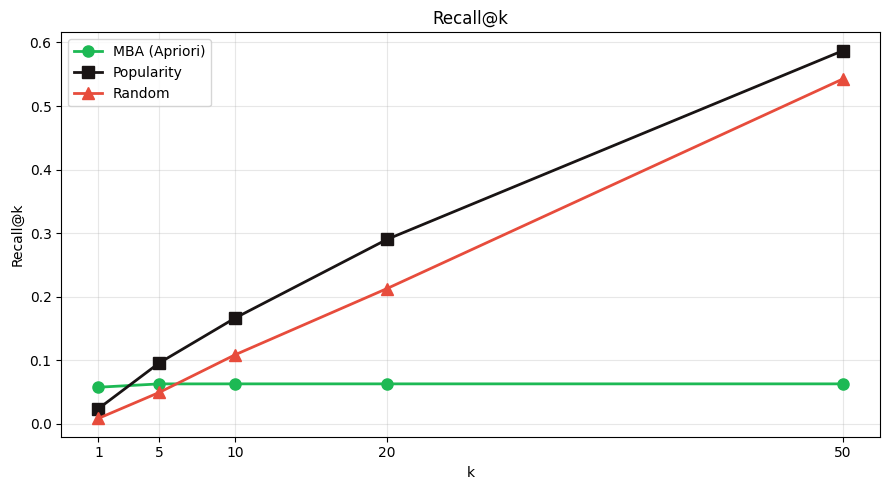

In [69]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_VALUES, mba_r,  'o-', color=COLOR_MBA,  linewidth=2, markersize=8, label='MBA (Apriori)')
ax.plot(K_VALUES, pop_r,  's-', color=COLOR_POP,  linewidth=2, markersize=8, label='Popularity')
ax.plot(K_VALUES, rand_r, '^-', color=COLOR_RAND, linewidth=2, markersize=8, label='Random')
ax.set_xlabel('k')
ax.set_ylabel('Recall@k')
ax.set_title('Recall@k')
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

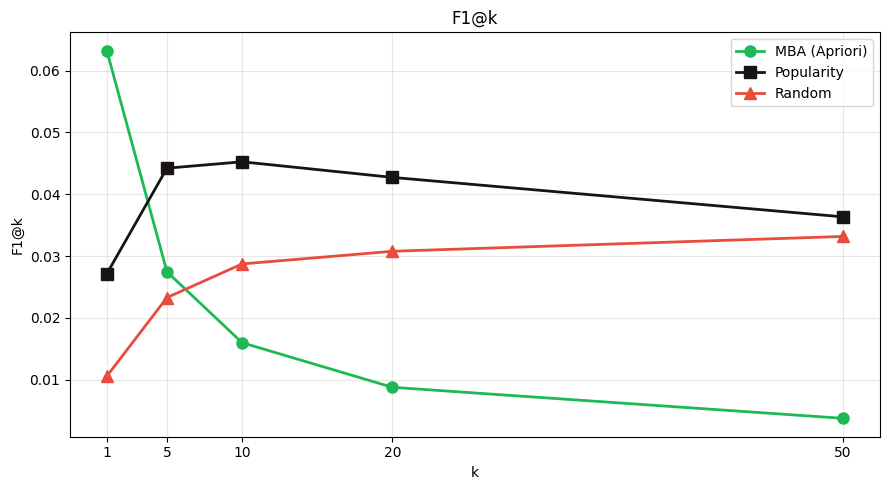

In [70]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_VALUES, mba_f,  'o-', color=COLOR_MBA,  linewidth=2, markersize=8, label='MBA (Apriori)')
ax.plot(K_VALUES, pop_f,  's-', color=COLOR_POP,  linewidth=2, markersize=8, label='Popularity')
ax.plot(K_VALUES, rand_f, '^-', color=COLOR_RAND, linewidth=2, markersize=8, label='Random')
ax.set_xlabel('k')
ax.set_ylabel('F1@k')
ax.set_title('F1@k')
ax.set_xticks(K_VALUES)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

vocab=  25  runtime=   0.02s  itemsets=325
vocab=  50  runtime=   0.05s  itemsets=1,275
vocab=  75  runtime=   0.09s  itemsets=2,850
vocab= 100  runtime=   0.21s  itemsets=5,050
vocab= 150  runtime=   0.53s  itemsets=11,307
vocab= 200  runtime=   0.99s  itemsets=19,836
vocab= 300  runtime=   3.47s  itemsets=42,124
vocab= 500  runtime=  15.62s  itemsets=89,728


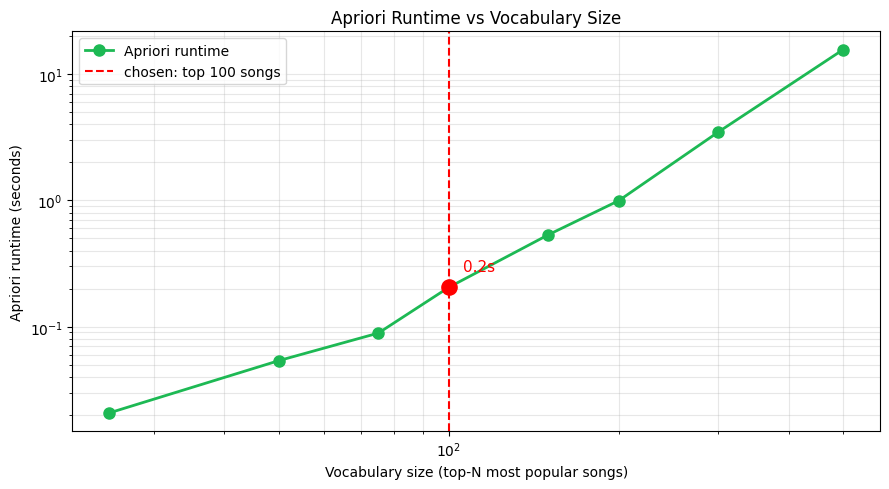


At vocab=100: 0.21s, 5,050 itemsets


In [71]:
import time

VOCAB_SIZES = [25, 50, 75, 100, 150, 200, 300, 500]
TIMEOUT_SEC = 90  # bail out of the sweep if any single run exceeds this
SWEEP_MIN_SUPPORT = 0.0005  # match the methodology paper's chosen threshold

# count song frequencies once across the full transactions
all_song_counts = Counter(item for t in transactions for item in t)

vocab_runtimes = []
vocab_itemset_counts = []
vocab_sizes_actual = []

for n in VOCAB_SIZES:
    top_n_songs = {s for s, _ in all_song_counts.most_common(n)}
    filtered = [[s for s in t if s in top_n_songs] for t in transactions]
    filtered = [t for t in filtered if len(t) >= 2]

    te_sweep = TransactionEncoder()
    df_sweep = pd.DataFrame(te_sweep.fit_transform(filtered), columns=te_sweep.columns_)

    start = time.perf_counter()
    freq_sweep = apriori(df_sweep, min_support=SWEEP_MIN_SUPPORT,
                         use_colnames=True, max_len=2)
    elapsed = time.perf_counter() - start

    vocab_sizes_actual.append(n)
    vocab_runtimes.append(elapsed)
    vocab_itemset_counts.append(len(freq_sweep))
    print(f"vocab={n:>4}  runtime={elapsed:>7.2f}s  itemsets={len(freq_sweep):,}")

    if elapsed > TIMEOUT_SEC:
        print(f"  hit timeout, stopping sweep")
        break

CHOSEN_VOCAB = 100  # match what the notebook actually uses

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(vocab_sizes_actual, vocab_runtimes, 'o-',
        color=COLOR_MBA, linewidth=2, markersize=8, label='Apriori runtime')

# Mark the chosen vocabulary
chosen_idx = vocab_sizes_actual.index(CHOSEN_VOCAB) if CHOSEN_VOCAB in vocab_sizes_actual else None
if chosen_idx is not None:
    ax.axvline(CHOSEN_VOCAB, color='red', linestyle='--', linewidth=1.5,
               label=f'chosen: top {CHOSEN_VOCAB} songs')
    ax.scatter([CHOSEN_VOCAB], [vocab_runtimes[chosen_idx]], color='red', s=120, zorder=5)
    ax.annotate(f'{vocab_runtimes[chosen_idx]:.1f}s',
                xy=(CHOSEN_VOCAB, vocab_runtimes[chosen_idx]),
                xytext=(10, 12), textcoords='offset points',
                fontsize=11, color='red')

ax.set_xscale('log')
ax.set_yscale('log')   # runtime grows roughly exponentially, log shows it cleanly
ax.set_xlabel('Vocabulary size (top-N most popular songs)')
ax.set_ylabel('Apriori runtime (seconds)')
ax.set_title('Apriori Runtime vs Vocabulary Size')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nAt vocab={CHOSEN_VOCAB}: {vocab_runtimes[chosen_idx]:.2f}s, "
      f"{vocab_itemset_counts[chosen_idx]:,} itemsets")

min_support=0.0001   itemsets=166,278
min_support=0.0002   itemsets=164,431
min_support=0.0005   itemsets=139,985
min_support=0.001    itemsets=82,663
min_support=0.002    itemsets=32,132
min_support=0.005    itemsets=4,592
min_support=0.01     itemsets=807
min_support=0.02     itemsets=161
min_support=0.05     itemsets=63


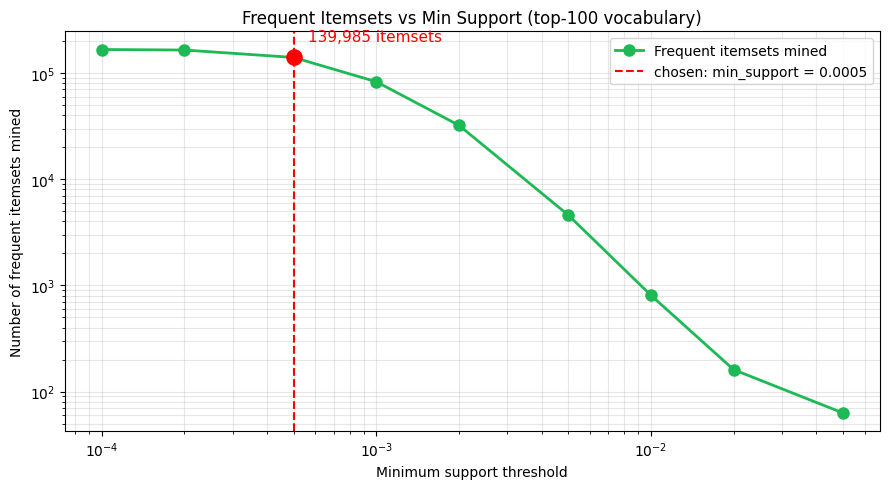

In [72]:
SUPPORT_SWEEP = [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

# Build the top-100 transaction matrix once (reuse for every threshold)
top_100_full = {s for s, _ in all_song_counts.most_common(100)}
filtered_full = [[s for s in t if s in top_100_full] for t in transactions]
filtered_full = [t for t in filtered_full if len(t) >= 2]

te_full = TransactionEncoder()
df_full = pd.DataFrame(te_full.fit_transform(filtered_full), columns=te_full.columns_)

itemsets_at_support = []
for s in SUPPORT_SWEEP:
    freq = apriori(df_full, min_support=s, use_colnames=True, max_len=3)
    itemsets_at_support.append(len(freq))
    print(f"min_support={s:<7}  itemsets={len(freq):,}")

CHOSEN_SUPPORT = 0.0005  # match the methodology paper's chosen value
chosen_idx = SUPPORT_SWEEP.index(CHOSEN_SUPPORT)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(SUPPORT_SWEEP, itemsets_at_support, 'o-',
        color=COLOR_MBA, linewidth=2, markersize=8, label='Frequent itemsets mined')

# Mark the chosen threshold
ax.axvline(CHOSEN_SUPPORT, color='red', linestyle='--', linewidth=1.5,
           label=f'chosen: min_support = {CHOSEN_SUPPORT}')
ax.scatter([CHOSEN_SUPPORT], [itemsets_at_support[chosen_idx]],
           color='red', s=120, zorder=5)
ax.annotate(f'{itemsets_at_support[chosen_idx]:,} itemsets',
            xy=(CHOSEN_SUPPORT, itemsets_at_support[chosen_idx]),
            xytext=(10, 12), textcoords='offset points',
            fontsize=11, color='red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Minimum support threshold')
ax.set_ylabel('Number of frequent itemsets mined')
ax.set_title('Frequent Itemsets vs Min Support (top-100 vocabulary)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()